# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

### This is a notebook for extracting and exploring data from XML files. 

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Corpus Description

92 scientific articles are drawn from PeerJ's publications in the decade spanning 2013 to 2023 (18 from 2013, 37 from 2018, and 37 from 2023). Articles are sorted by PeerJ's determination of relevance to the query "climate change." The top 30 most relevant articles per year, after meeting these described criteria, have then been chosen to comprise my corpus.

### Imports

In [145]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)


# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Creating DOC Table

In [146]:
# Downloading files 
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

# Iterate through files, grab XML info, and save to a dictionary
docs = []
for i, source_file_path in enumerate(source_files_paths):

    tree = etree.parse(source_file_path)
    root = tree.getroot()
    
    pub_id_str = root.xpath("//front//article-meta//article-id")[1].text

    title_el = root.xpath("//front//article-title")[0]
    title_str = " ".join([t.strip() for t in title_el.itertext()])

    author_el = root.xpath("//front//article-meta//contrib-group//contrib//name")[0]
    author_str = " ".join([t.strip() for t in author_el.itertext()])

    year_str = root.xpath("//front//pub-date/year")[0].text
    month_str = root.xpath("//front//pub-date/month")[0].text
    day_str = root.xpath("//front//pub-date/day")[0].text
    date_str = "-".join([year_str, month_str, day_str])

    kwd_els = root.xpath("//kwd")
    kwd_strs = [kwd_el.text for kwd_el in kwd_els]

    p_els = root.xpath("//body//p")
    p_strs = []
    for p_el in p_els:
        etree.strip_elements(p_el, "xref", with_tail=False)
        p_str = etree.tostring(p_el, method="text", encoding="unicode")
        p_strs.append(p_str)
    
    docs.append({
        'doc_id': pub_id_str,
        'doc_title': title_str,
        'doc_1st_author': author_str,
        'doc_date': date_str,
        'doc_content': " ".join(p_strs),
        'doc_kws': kwd_strs,
        'doc_file_path': source_file_path
    })

# Convert dictionary to data frame
DOC = pd.DataFrame(docs) 
del(docs)
DOC.head()

,doc_id,doc_title,doc_1st_author,doc_date,doc_content,doc_kws,doc_file_path
0,10.7717/peerj.6130,Local persistence of Mann’s soft-haired mouse ...,Valdez Lourdes,2018-12-18,The southern cone of South America has been th...,"[Lowland coastal refugium, Pleistocene, Patago...",sources\Abrothrix_manni_2018.xml
1,10.7717/peerj.16574,Acute heat priming promotes short-term climate...,Glass Benjamin H.,2023-12-5,Anthropogenic ocean warming threatens the surv...,"[None, Hormetic priming, Environmental memory,...",sources\Acute_heat_2023.xml
2,10.7717/peerj.6133,Effects of ultraviolet radiation on metabolic ...,Villena Oswaldo C.,2018-12-18,"Environmental changes (e.g., global warming, c...","[Metabolic rate, Microbial communities, UV-B r...",sources\Aedes_albopictus_2018.xml
3,10.7717/peerj.5801,Agrichemicals and antibiotics in combination i...,Kurenbach Brigitta,2018-10-12,Neither reducing the use of antibiotics nor di...,"[Antibiotic resistance, Herbicide, Minimum sel...",sources\Agrichemicals_2018.xml
4,10.7717/peerj.188,Transformative optimisation of agricultural la...,Koh Lian Pin,2013-10-24,"By 2050, the global human population will have...","[Food security, Deforestation, Climate change,...",sources\Agricultural_2013.xml


In [147]:
# Save to CSV
DOC.to_csv("csvs/DOC/DOC.csv", index=True)

In [148]:
DOC['year'] = DOC['doc_date'].str[:4]
DOC['mth_day'] = DOC['doc_date'].str[5:]
DOC = DOC.copy()
DOC_to_join = DOC.drop(columns=['doc_id', 'doc_title', 'doc_1st_author', 'doc_date', 'doc_content', 'doc_kws', 'doc_file_path'])
DOC_to_join.index.rename('doc_id', inplace=True)
DOC_to_join.head()

,year,mth_day
doc_id,,
0,2018,12-18
1,2023,12-5
2,2018,12-18
3,2018,10-12
4,2013,10-24


### Creating SENTS Table

In [149]:
# Parse into Sentences with NLTK
SENTS = DOC.doc_content.apply(lambda x: pd.Series(nltk.sent_tokenize(x), dtype='string')).stack().to_frame('sent_str')
SENTS = SENTS.sent_str[SENTS.sent_str.apply(lambda x: isinstance(x, str))] # From Claude
SENTS.index.names = ['doc_id','sent_num']
SENTS = SENTS.to_frame()
SENTS.head()

sent_str
doc_id sent_num                                                   
0      0         The southern cone of South America has been th...
       1         The Quaternary period was marked by a complex ...
       2         A “Great Patagonian Glaciation” (GPG) occurred...
       3         The most recent of these events was the Last G...
       4         During the LGM, an ice sheet 1,800 km long bui...

In [150]:
# Saving to CSV
SENTS.to_csv("csvs/SENTS/SENTS.csv", index=True)

### Creating LIB Table

In [166]:
# Joining with DOC_to_join to be able to group by year
LIB = DOC.join(DOC_to_join, lsuffix='_L', rsuffix='_R')
LIB = LIB.drop(columns=['doc_id', 'doc_date', 'doc_kws',  'doc_file_path', 'mth_day_L', 'mth_day_R', 'year_R', 'doc_content'])
LIB.index.name = 'doc_id'

# Grouping SENTS df to obtain full doc content
SENTS_joined = SENTS.join(DOC_to_join)

# # Joining the two 
LIB = LIB.copy()
LIB = LIB.join(SENTS_joined)
#LIB.groupby(LIB.index).agg(' '.join) - does not work - corrected by Claude below

LIB = LIB.groupby(level=0).agg({
    'doc_title': 'first',   # Same for all rows in a doc
    'doc_1st_author': 'first',
    'year_L':    'first',
    'year':      'first',
    'mth_day':   'first',
    'sent_str':  ' '.join,  # Concatenate all sentences together
})


LIB['num_words'] = LIB['sent_str'].str.split().str.len() # From Claude
LIB['num_chars'] = LIB['sent_str'].str.len()

# Some extra cleanup
LIB.drop(columns=['year_L', 'mth_day'], inplace=True)

LIB = LIB.sort_values('year')

LIB.head()

,doc_title,doc_1st_author,year,sent_str,num_words,num_chars
doc_id,,,,,,
9,Timing of molt of barn swallows is delayed in ...,Saino Nicola,2013,Organisms are selected to match the timing of ...,4557,28640
60,Microbial secondary succession in soil microco...,López-Lozano Nguyen E.,2013,"In ecological theory, succession is defined as...",5382,35503
69,Some poleward movement of British native vascu...,Groom Quentin J.,2013,"Among animals, numerous studies have shown rec...",3288,20873
42,Does haemosporidian infection affect hematolog...,Motta Rafael Otávio Cançado,2013,Infectious diseases can greatly impact local s...,3184,21592
13,Bird migratory flyways influence the phylogeog...,Muñoz Joaquín,2013,"Since , the role of birds as dispersal vectors...",6328,42164


In [167]:
# Saving to CSV
LIB.to_csv("csvs/LIB/LIB.csv", index=True)
print(LIB['num_chars'].mean())

print(LIB['num_words'].mean())

38815.239130434784
5712.086956521739


### Visualization: Plotting Document Length

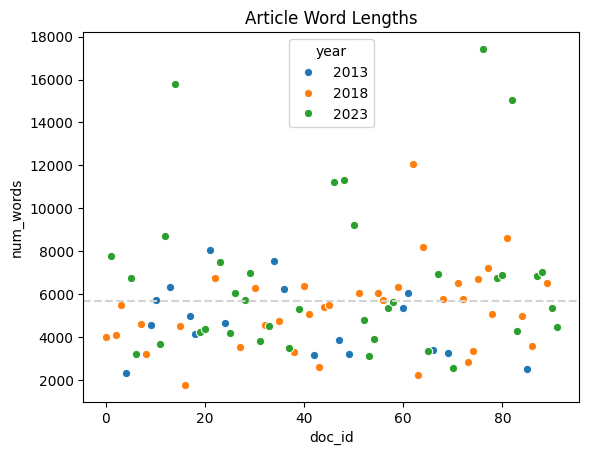

In [171]:
sns.lineplot(LIB, x='doc_id', y='num_words', hue=LIB['year'], marker='o',linestyle='')

# Add labels
ax = plt.gca() # Get the current axes

# Add the mean of the feature as dotted lines
ax.axhline(LIB.num_words.mean(), c='lightgray', ls='--')    

plt.title("Article Word Lengths")

plt.show()

Articles from 2013 and 2018 consistently fall below the mean, while articles from 2023 fall above the mean more often and have more high-length outliers. This leads to a conclusion that articles are getting longer in 2023; perhaps this is due to increased pressure on scientists to "publish or perish" as the field inevitably becomes more competitive, or perhaps this is due to greater and greater dataset sizes available as satellites continue to gather data. It is of course possible that this relatively small sample size (about 100 articles) means these data are just noise; future directions include expanding the corpus to see if these findings persist.

### Creating TOKENS Table

In [154]:
SENTS

sent_str
doc_id sent_num                                                   
0      0         The southern cone of South America has been th...
       1         The Quaternary period was marked by a complex ...
       2         A “Great Patagonian Glaciation” (GPG) occurred...
       3         The most recent of these events was the Last G...
       4         During the LGM, an ice sheet 1,800 km long bui...
...                                                            ...
91     209       Inoculations of WR22 and WR24 were found promi...
       210       Phylogenetic analysis revealed the highest sim...
       211       This is the first report on the novel associat...
       212       Conclusively, C. campinesis WR22 and E. ludwig...
       213           Each bacteria was streaked on a single plate.

[21171 rows x 1 columns]

In [155]:
# Parse into Tokens with NLTK
TOKENS = SENTS.sent_str.apply(lambda x: pd.Series(nltk.pos_tag(nltk.word_tokenize(x)))).stack().to_frame('pos_tuple')
TOKENS = TOKENS.dropna()
TOKENS['pos'] = TOKENS.pos_tuple.apply(lambda x: x[1])
TOKENS['pos_group'] = TOKENS.pos.str[:2]
TOKENS['token_str'] = TOKENS.pos_tuple.apply(lambda x: x[0])
TOKENS = TOKENS.drop('pos_tuple', axis=1)
TOKENS['term_str'] = TOKENS.token_str.str.lower().str.replace(r"[\W_]+", "", regex=True) 
TOKENS = TOKENS[TOKENS.term_str != ''].copy()
TOKENS.index.names = SENTS.index.names + ['token_num']

TOKENS.head()

pos pos_group token_str  term_str
doc_id sent_num token_num                                   
0      0        0           DT        DT       The       the
                1           JJ        JJ  southern  southern
                2           NN        NN      cone      cone
                3           IN        IN        of        of
                4          NNP        NN     South     south

In [156]:
TOKENS = TOKENS.join(DOC_to_join)
TOKENS = TOKENS.set_index('year', append=True)
TOKENS = TOKENS.set_index('mth_day', append=True)
TOKENS = TOKENS.reorder_levels([3,4,0,1,2])
TOKENS.head(30)

pos pos_group   token_str    term_str
year mth_day doc_id sent_num token_num                                       
2018 12-18   0      0        0           DT        DT         The         the
                             1           JJ        JJ    southern    southern
                             2           NN        NN        cone        cone
                             3           IN        IN          of          of
                             4          NNP        NN       South       south
                             5          NNP        NN     America     america
                             6          VBZ        VB         has         has
                             7          VBN        VB        been        been
                             8           DT        DT         the         the
                             9           NN        NN     setting     setting
                             10          IN        IN          of          of
                             11          JJ        JJ       major       major
                             12          JJ        JJ    climatic    climatic
                             14          JJ        JJ    tectonic    tectonic
                             15          CC        CC         and         and
                             16          JJ        JJ    volcanic    volcanic
                             17          NN        NN    activity    activity
                             18          IN        IN      during      during
                             19          DT        DT         the         the
                             20          JJ        JJ        past        past
                             21          JJ        JJ     several     several
                             22          CD        CD     million     million
                             23         NNS        NN       years       years
                    1        0           DT        DT         The         the
                             1          NNP        NN  Quaternary  quaternary
                             2           NN        NN      period      period
                             3          VBD        VB         was         was
                             4          VBN        VB      marked      marked
                             5           IN        IN          by          by
                             6           DT        DT           a           a

In [168]:
# Also known as CORPUS
CORPUS = TOKENS.copy()
print(len(CORPUS))

513675


In [158]:
# Saving to CSV
TOKENS.to_csv("csvs/TOKENS/TOKENS.csv", index=True)
CORPUS.to_csv("csvs/CORPUS/CORPUS.csv", index=True)

### Creating Keywords Table

In [159]:
DOCKW = DOC.doc_kws.apply(pd.Series).stack().to_frame('doc_kw')
DOCKW.index.names = ['doc_id', 'kw_num']
DOCKW.head()

doc_kw
doc_id kw_num                          
0      0       Lowland coastal refugium
       1                    Pleistocene
       2                      Patagonia
       3                 Phylogeography
       4          Historical demography

In [160]:
KW = DOCKW.doc_kw.value_counts().to_frame('n')
KW.head()

,n
doc_kw,
Climate change,8
Conservation,7
Biodiversity,6
Birds,4
\n,4


### Create VOCAB Table

In [161]:
VOCAB = TOKENS.term_str.groupby(level='year').value_counts().to_frame('n')
VOCAB.index.name = 'term_str'
# Get overall probability (not as useful)
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
# Get information
VOCAB['i'] = -np.log2(VOCAB.p)
# Get information, probability per year
years = ['2013', '2018', '2023']
for year in years:
    mask = VOCAB.index.get_level_values('year') == year # Added by Claude
    year_n = VOCAB.loc[mask, 'n']
    VOCAB.loc[mask, 'p_yr'] = (year_n / year_n.sum()).values # Small Claude fixes
    VOCAB.loc[mask, 'i_yr'] = (-np.log2(year_n / year_n.sum())).values # From Claude
VOCAB

n         p          i      p_yr       i_yr
year term_str                                                    
2013 the           4963  0.009662   6.693500  0.059097   4.080779
     of            3106  0.006047   7.369654  0.036985   4.756933
     and           2631  0.005122   7.609101  0.031329   4.996380
     in            2310  0.004497   7.796819  0.027506   5.184098
     to            1710  0.003329   8.230716  0.020362   5.617995
...                 ...       ...        ...       ...        ...
2023 scpi             1  0.000002  18.970496  0.000004  17.864035
     fba              1  0.000002  18.970496  0.000004  17.864035
     sip11            1  0.000002  18.970496  0.000004  17.864035
     eno              1  0.000002  18.970496  0.000004  17.864035
     conclusively     1  0.000002  18.970496  0.000004  17.864035

[40776 rows x 5 columns]

In [ ]:
# Saving to CSV
VOCAB.to_csv("csvs/VOCAB/VOCAB.csv", index=True)

40776
